In [2]:
%pip install xlrd openpyxl

Note: you may need to restart the kernel to use updated packages.


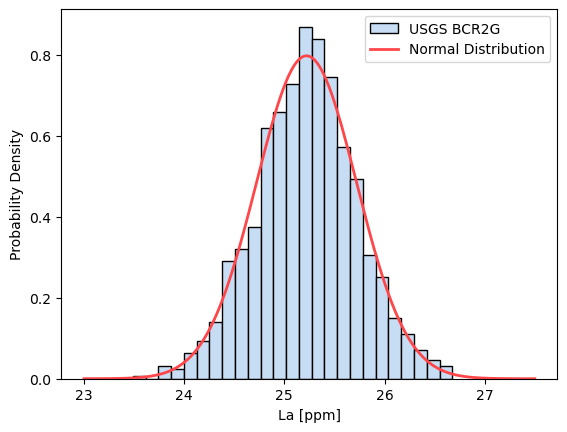

In [19]:
import pandas as pd              # Mengimpor library pandas untuk manipulasi data tabel (DataFrame)
import scipy.stats as stats      # Mengimpor modul statistik dari scipy untuk distribusi probabilitas (misalnya normal distribution)
import matplotlib.pyplot as plt  # Mengimpor pyplot untuk membuat grafik/plot
import numpy as np               # Mengimpor numpy untuk komputasi numerik dan array

my_dataset = pd.read_excel('USGS_BCR2G.xls', sheet_name='Sheet1')
# Membaca file Excel bernama 'USGS_BCR2G.xls' pada sheet 'Sheet1' dan menyimpannya ke DataFrame

fig, ax = plt.subplots()
# Membuat figure (wadah grafik) dan axes (area plot) untuk menggambar grafik

ax.hist(my_dataset.La, bins='auto', density=True, edgecolor='#000000', color='#c7ddf4', label="USGS BCR2G")
# Membuat histogram dari kolom La (konsentrasi La dalam ppm)
# bins='auto' → jumlah bin ditentukan otomatis
# density=True → menormalkan histogram menjadi probabilitas (luas total = 1)
# edgecolor → warna garis tepi batang histogram
# color → warna isi histogram
# label → nama dataset untuk legenda

ax.set_xlabel("La [ppm]")
# Memberi label pada sumbu X (konsentrasi La dalam ppm)

ax.set_ylabel("Probability Density")
# Memberi label pada sumbu Y (kepadatan probabilitas)

x = np.linspace(23,27.5,500)
# Membuat 500 titik data dari 23 sampai 27.5 untuk membentuk kurva halus distribusi normal

pdf = stats.norm(loc=my_dataset.La.mean(), scale=my_dataset.La.std()).pdf(x)
# Membuat distribusi normal berdasarkan:
# loc → rata-rata data La
# scale → standar deviasi data La
# lalu menghitung nilai probability density function (PDF) pada setiap nilai x

ax.plot(x,pdf, linewidth=2, color='#ff464a', label='Normal Distribution')
# Menggambar kurva distribusi normal di atas histogram
# linewidth → ketebalan garis
# color → warna garis
# label → nama untuk legenda

ax.legend()
# Menampilkan legenda pada grafik

plt.show()
# Menampilkan grafik ke layar

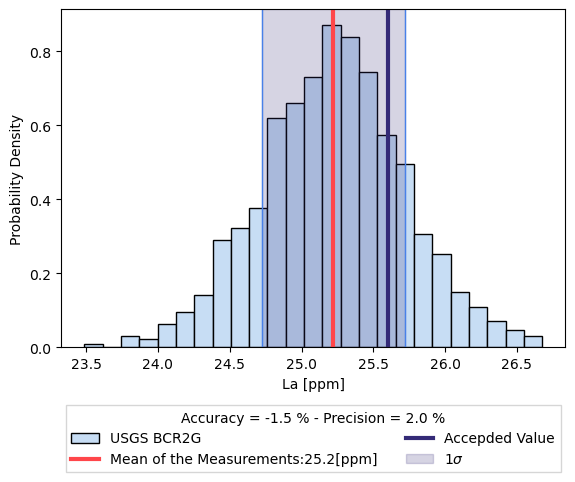

In [20]:
my_mean = my_dataset.La.mean()
# Menghitung rata-rata (mean) dari data kolom La

R = 25.6
# Menentukan nilai referensi/standar (accepted value)

accuracy = 100 * (my_mean - R) / R
# Menghitung akurasi dalam persen berdasarkan selisih mean terhadap nilai referensi R

my_std = my_dataset.La.std()
# Menghitung standar deviasi (sebaran data) dari kolom La

precision = 100 * my_std / R
# Menghitung presisi dalam persen berdasarkan standar deviasi relatif terhadap nilai R


fig, ax = plt.subplots(figsize=(6,5))
# Membuat figure dan axes dengan ukuran 6x5 inch

ax.hist(my_dataset.La, bins = 'auto', density = True, edgecolor = '#000000', color = '#c7ddf4', label = 'USGS BCR2G')
# Membuat histogram data La:
# bins='auto' → jumlah bin otomatis
# density=True → normalisasi ke probabilitas
# edgecolor → warna garis tepi
# color → warna batang histogram
# label → nama dataset

ax.set_xlabel('La [ppm]')
# Memberi label sumbu X

ax.set_ylabel('Probability Density')
# Memberi label sumbu Y


ax.axvline(x=my_dataset.La.mean(), color='#ff464a', linewidth=3, label='Mean of the Measurements:' + str(round(my_mean, 1)) + '[ppm]')
# Menambahkan garis vertikal pada nilai mean data
# linewidth → ketebalan garis
# label → menampilkan nilai mean pada legenda (dibulatkan 1 desimal)

ax.axvline(x = R, color='#342a77', linewidth=3, label='Accepded Value')
# Menambahkan garis vertikal untuk nilai referensi/accepted value (R)

ax.axvline(x = my_mean - my_std, color = '#4881e9', linewidth = 1)
# Menambahkan garis batas bawah 1 standar deviasi dari mean

ax.axvline(x = my_mean + my_std, color = '#4881e9', linewidth = 1)
# Menambahkan garis batas atas 1 standar deviasi dari mean

ax.axvspan(my_mean - my_std,  my_mean + my_std, alpha = 0.2, color = '#342a77', label = r'$1\sigma$')
# Memberi shading (area berwarna) antara -1σ sampai +1σ
# alpha → transparansi warna
# r'$1\sigma$' → label matematika untuk 1 standar deviasi

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=False, shadow=False, ncol=2, title = 'Accuracy = {:.1f} % - Precision = {:.1f} %'.format(accuracy, precision))
# Menampilkan legenda:
# loc + bbox_to_anchor → posisi legenda di luar plot (bagian bawah tengah)
# ncol=2 → legenda dibuat 2 kolom
# title → menampilkan nilai accuracy dan precision yang diformat 1 angka desimal

fig.tight_layout()
# Mengatur layout agar elemen grafik tidak saling tumpang tindih

plt.show()
# Menampilkan grafik ke layar

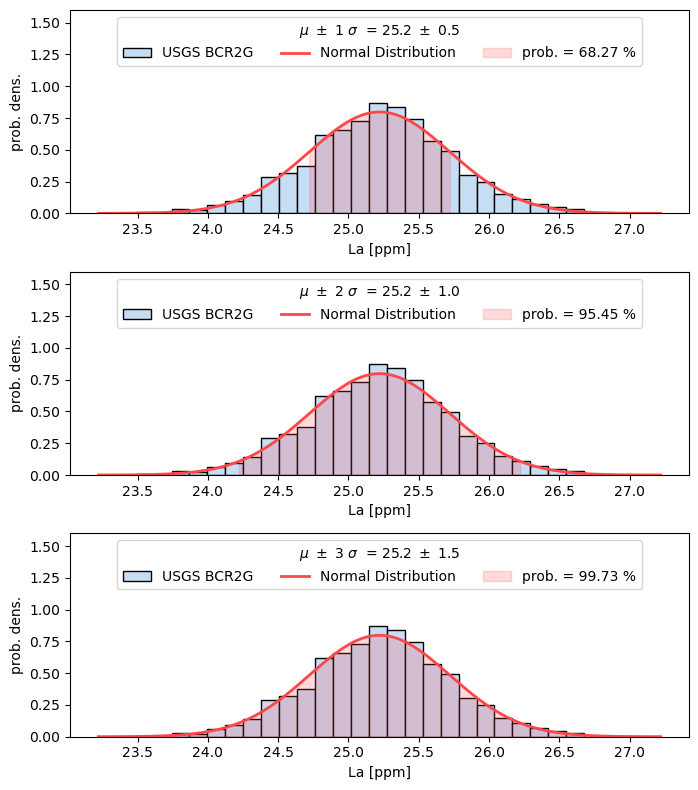

In [21]:
import numpy as np              # Mengimpor NumPy untuk perhitungan numerik
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk membuat grafik

def normal_pdf(x, mu, sigma):
    # Membuat fungsi probability density function (PDF) distribusi normal
    pdf = 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2 / (2*sigma**2))
    # Rumus distribusi normal (Gaussian)
    return pdf
    # Mengembalikan nilai PDF

signa_levels = [1, 2, 3]
# Menentukan level sigma (1σ, 2σ, 3σ)

confidences = [68.27, 95.45, 99.73]
# Persentase confidence interval untuk masing-masing sigma (aturan 68-95-99.7)

fig = plt.figure(figsize=(7,8))
# Membuat figure dengan ukuran 7x8 inch

my_mean = my_dataset.La.mean()
# Menghitung rata-rata data La

my_std = my_dataset.La.std()
# Menghitung standar deviasi data La

x_pdf = np.linspace(my_mean - 4 * my_std, my_mean + 4 * my_std, 1000)
# Membuat 1000 titik dari -4σ sampai +4σ untuk menggambar kurva normal

my_pdf = normal_pdf(x_pdf, my_mean, my_std)
# Menghitung nilai PDF distribusi normal pada semua titik x_pdf


for signa_level, confidence in zip(signa_levels,confidences):
    # Loop untuk setiap level sigma dan confidence

    ax = fig.add_subplot(3, 1, signa_level)
    # Membuat subplot (3 baris, 1 kolom, posisi sesuai sigma level)

    ax.hist(my_dataset.La, bins='auto', density=True, edgecolor='#000000', color='#c7ddf4', label='USGS BCR2G', zorder=0)
    # Membuat histogram data La dengan normalisasi probabilitas

    x_confidence = np.linspace(my_mean - signa_level * my_std, my_mean + signa_level * my_std, 1000)
    # Menentukan rentang x untuk area confidence interval (±1σ, ±2σ, ±3σ)

    ax.plot(x_pdf, my_pdf, linewidth=2, color='#ff464a', label='Normal Distribution', zorder=1)
    # Menggambar kurva distribusi normal

    ax.fill_between(
        x_confidence,
        normal_pdf(x_confidence, my_mean, my_std),
        y2=0,
        color='#ff464a',
        alpha=0.2,
        label='prob. = {}'.format(confidence) + ' %',
        zorder=1
    )
    # Mengisi area di bawah kurva normal pada interval confidence (visualisasi probabilitas)

    ax.legend(
        ncol=3,
        loc='upper center',
        title=r'$\mu~ \pm ~$' + str(signa_level) + r'$ ~ \sigma ~ $ = ' + '{:.1f}'.format(my_mean) + r'$~ \pm ~$' + '{:.1f}'.format(signa_level * my_std)
    )
    # Menampilkan legenda:
    # ncol=3 → 3 kolom
    # title → menampilkan mean ± sigma dalam format matematis

    ax.set_ylim(0,1.6)
    # Mengatur batas maksimum sumbu Y

    ax.set_xlabel('La [ppm]')
    # Memberi label sumbu X

    ax.set_ylabel('prob. dens.')
    # Memberi label sumbu Y (probability density)


fig.tight_layout()
# Mengatur layout agar subplot tidak saling tumpang tindih

plt.show()
# Menampilkan seluruh grafik

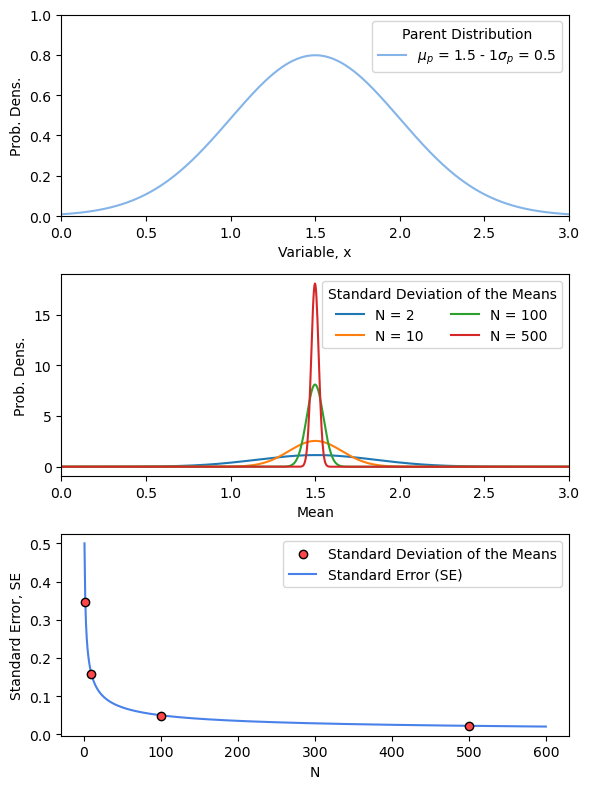

In [22]:
import numpy as np              # Mengimpor NumPy untuk perhitungan numerik (array, statistik)
import scipy.stats as stats     # Mengimpor modul statistik (distribusi probabilitas, sampling)
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk membuat grafik

mean_value = 1.5
# Menentukan nilai rata-rata (mean) dari distribusi normal

std_dev = 0.5
# Menentukan standar deviasi (sigma) dari distribusi normal

dist = stats.norm(loc=mean_value, scale=std_dev) 
# Membuat distribusi normal dengan mean = 1.5 dan std dev = 0.5

x = np.linspace(0, 3, 1000)
# Membuat 1000 titik data dari 0 sampai 3 untuk kurva PDF

fig = plt.figure(figsize=(6,8))
# Membuat figure dengan ukuran 6x8 inch


# =========================
# 1. DISTRIBUSI ASLI (PDF)
# =========================

pdf = dist.pdf(x)
# Menghitung nilai probability density function (PDF) pada setiap x

ax1 = fig.add_subplot(3, 1, 1)
# Membuat subplot 1 dari 3 (baris 3 kolom 1, posisi 1)

ax1.plot(x, pdf, color='#84b4e8', label =r'$\mu_p$ = 1.5 - 1$\sigma_p$ = 0.5')
# Menggambar kurva distribusi normal
# label menunjukkan mean dan standar deviasi

ax1.set_xlim(0,3)
# Mengatur batas sumbu X

ax1.set_ylim(0,1)
# Mengatur batas sumbu Y

ax1.set_xlabel('Variable, x')
# Label sumbu X

ax1.set_ylabel('Prob. Dens.')
# Label sumbu Y

ax1.legend(title = 'Parent Distribution')
# Menampilkan legenda grafik


# ==========================================
# 2. CENTRAL LIMIT THEOREM (DISTRIBUSI MEAN)
# ==========================================

ax2 = fig.add_subplot(3, 1, 2)
# Membuat subplot 2

std_of_the_mean = []
# List untuk menyimpan standar deviasi dari distribusi mean

ns = [2, 10, 100, 500]
# Ukuran sampel (jumlah data per percobaan)

for n in ns:
    # Loop untuk setiap ukuran sampel

    mean_dist = []
    # Menyimpan hasil rata-rata dari banyak percobaan

    for _ in range(1000):
        # Melakukan 1000 kali eksperimen
        mean_dist.append(dist.rvs(size=n).mean())
        # Mengambil sampel acak dari distribusi lalu menghitung mean

    mean_dist = np.array(mean_dist)
    # Mengubah list menjadi array NumPy

    std_of_the_mean.append(mean_dist.std())
    # Menghitung standar deviasi dari distribusi mean

    normal = stats.norm(loc=mean_dist.mean(), scale=mean_dist.std())
    # Membuat distribusi normal dari hasil mean sampel

    ax2.plot(x, normal.pdf(x), label='N = ' + str(n))
    # Menggambar distribusi mean untuk setiap ukuran sampel


ax2.set_xlim(0, 3)
# Batas sumbu X

ax2.set_xlabel('Mean')
# Label sumbu X

ax2.set_ylabel('Prob. Dens.')
# Label sumbu Y

ax2.legend(title='Standard Deviation of the Means', ncol=2)
# Menampilkan legenda dengan 2 kolom


# ==========================================
# 3. STANDARD ERROR vs SAMPLE SIZE
# ==========================================

ax3 = fig.add_subplot(3, 1, 3)
# Membuat subplot 3

ax3.scatter(ns, std_of_the_mean, color='#ff464a', edgecolor='#000000',
            label='Standard Deviation of the Means', zorder=1)
# Menampilkan hasil simulasi standar deviasi mean (titik scatter)

n1 = np.linspace(1, 600, 600)
# Membuat range nilai N dari 1 sampai 600

se = std_dev / np.sqrt(n1)
# Menghitung Standard Error teoritis (SE = σ / √N)

ax3.plot(n1 , se, c='#4881e9', label='Standard Error (SE)', zorder=0)
# Menggambar kurva SE teoritis

ax3.set_xlabel('N')
# Label sumbu X

ax3.set_ylabel('Standard Error, SE')
# Label sumbu Y

ax3.legend()
# Menampilkan legenda

fig.tight_layout()
# Mengatur layout agar subplot tidak saling tumpang tindih

plt.show()
# Menampilkan semua grafik

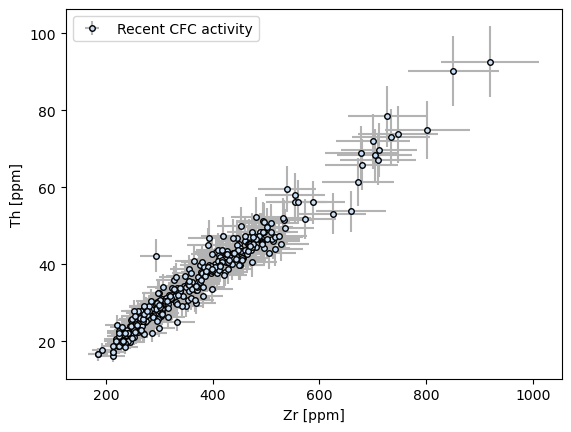

In [23]:
import pandas as pd              # Mengimpor pandas untuk membaca dan mengolah data tabel (Excel/DataFrame)
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk membuat grafik

my_dataset1 = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')
# Membaca file Excel dan mengambil sheet 'Supp_traces' ke dalam DataFrame

x = my_dataset1.Zr
# Mengambil kolom Zr sebagai data sumbu X (Zirconium dalam ppm)

y = my_dataset1.Th
# Mengambil kolom Th sebagai data sumbu Y (Thorium dalam ppm)

dx = my_dataset1.Zr * 0.1
# Menentukan error (ketidakpastian) pada Zr sebesar 10% dari nilai Zr

dy = my_dataset1.Th * 0.1
# Menentukan error pada Th sebesar 10% dari nilai Th


fig, ax = plt.subplots()
# Membuat figure dan axes untuk plotting

ax.errorbar(
    x, y,
    xerr=dx, yerr=dy,
    marker='o',
    markersize=4,
    linestyle='',
    color='#c7ddf4',
    markeredgecolor='k',
    ecolor='0.7',
    label='Recent CFC activity'
)
# Membuat scatter plot dengan error bar:
# xerr → error horizontal (Zr)
# yerr → error vertikal (Th)
# marker='o' → bentuk titik lingkaran
# markersize=4 → ukuran titik
# linestyle='' → tidak ada garis penghubung
# color → warna titik
# markeredgecolor → warna tepi titik (hitam)
# ecolor → warna error bar (abu-abu)
# label → nama data di legenda

ax.set_xlabel('Zr [ppm]')
# Memberi label sumbu X

ax.set_ylabel('Th [ppm]')
# Memberi label sumbu Y

ax.legend(loc='upper left')
# Menampilkan legenda di posisi kiri atas

plt.show()
# Menampilkan grafik

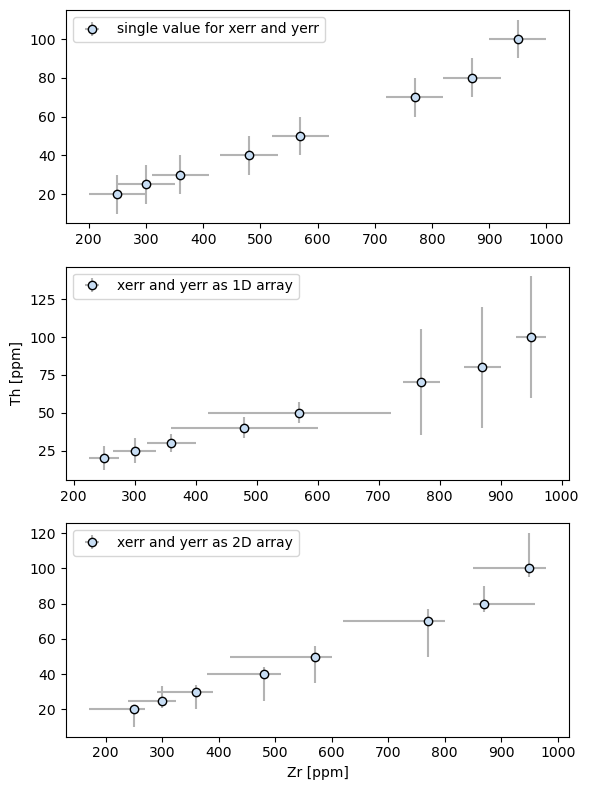

In [24]:
import numpy as np              # Mengimpor NumPy untuk operasi array dan numerik
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk membuat grafik

x = np.array([250,300,360,480,570,770,870,950])
# Data sumbu X (misalnya konsentrasi Zr dalam ppm)

y = np.array([20,25,30,40,50,70,80,100])
# Data sumbu Y (misalnya konsentrasi Th dalam ppm)


fig = plt.figure(figsize=(6,8))
# Membuat figure dengan ukuran 6x8 inch


# =========================================
# 1. ERROR BAR: nilai error tunggal (konstan)
# =========================================

dx = 50
# Error horizontal (xerr) sama untuk semua titik

dy = 10
# Error vertikal (yerr) sama untuk semua titik

ax1 = fig.add_subplot(3,1,1)
# Membuat subplot 1 (dari 3 baris, 1 kolom)

ax1.errorbar(
    x, y,
    xerr=dx, yerr=dy,
    marker='o',
    markersize=6,
    linestyle='',
    color='#c7ddf4',
    markeredgecolor='k',
    ecolor='0.7',
    label='single value for xerr and yerr'
)
# Membuat scatter plot dengan error bar konstan
# linestyle='' → tidak ada garis penghubung
# ecolor → warna error bar

ax1.legend(loc='upper left')
# Menampilkan legenda di kiri atas


# =========================================
# 2. ERROR BAR: error sebagai array 1D
# =========================================

dx = np.array([25,35,40,120,150,30,30,25])
# Error horizontal berbeda untuk tiap titik

dy = np.array([8,8,6,7,7,35,40,40])
# Error vertikal berbeda untuk tiap titik

ax2 = fig.add_subplot(3,1,2)
# Membuat subplot 2

ax2.errorbar(
    x, y,
    xerr=dx, yerr=dy,
    marker='o',
    markersize=6,
    linestyle='',
    color='#c7ddf4',
    markeredgecolor='k',
    ecolor='0.7',
    label='xerr and yerr as 1D array'
)
# Error bar dengan ketidakpastian berbeda untuk tiap data

ax2.set_ylabel('Th [ppm]')
# Label sumbu Y

ax2.legend(loc='upper left')
# Menampilkan legenda


# =========================================
# 3. ERROR BAR: error sebagai array 2D
# =========================================

dx = np.array([
    [80,60,70,100,150,150,20,100],  # lower error (bawah)
    [20,25,30,30,30,30,90,30]       # upper error (atas)
])
# Error horizontal asimetris (beda kiri dan kanan)

dy = np.array([
    [10,4,10,15,15,20,5,5],   # lower error (bawah)
    [2,8,4,4,6,7,10,20]       # upper error (atas)
])
# Error vertikal asimetris

ax3 = fig.add_subplot(3,1,3)
# Membuat subplot 3

ax3.errorbar(
    x, y,
    xerr=dx, yerr=dy,
    marker='o',
    markersize=6,
    linestyle='',
    color='#c7ddf4',
    markeredgecolor='k',
    ecolor='0.7',
    label='xerr and yerr as 2D array'
)
# Error bar dengan error asimetris (lebih realistis untuk data eksperimen)

ax3.set_xlabel('Zr [ppm]')
# Label sumbu X

ax3.legend(loc='upper left')
# Menampilkan legenda

fig.tight_layout()
# Mengatur layout agar subplot tidak saling tumpang tindih

plt.show()
# Menampilkan semua grafik

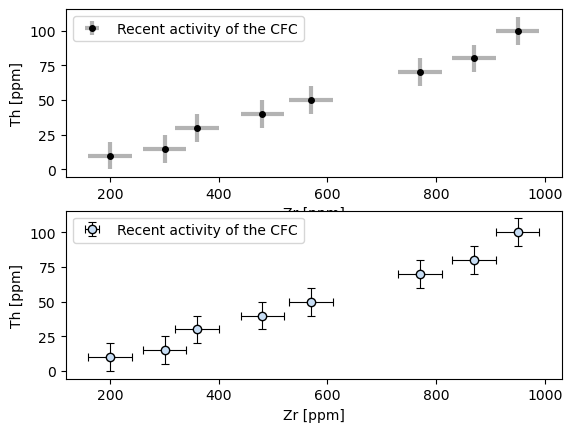

In [25]:
import numpy as np              # Mengimpor NumPy untuk operasi array dan perhitungan numerik
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk membuat grafik

x = np.array([200, 300, 360, 480, 570, 770, 870, 950])
# Data sumbu X (misalnya konsentrasi Zr dalam ppm)

y = np.array([10, 15, 30, 40, 50, 70, 80, 100])
# Data sumbu Y (misalnya konsentrasi Th dalam ppm)

dx = 40
# Error horizontal (xerr) konstan untuk semua titik

dy = 10
# Error vertikal (yerr) konstan untuk semua titik


fig = plt.figure()
# Membuat figure (wadah utama grafik)


# =========================================
# SUBPLOT 1: ERROR BAR sederhana (lebih tebal)
# =========================================

ax1 = fig.add_subplot(2, 1, 1)
# Membuat subplot 1 (2 baris, 1 kolom, posisi 1)

ax1.errorbar(
    x, y,
    xerr=dx, yerr=dy,
    marker='o',
    markersize=4,
    linestyle='',
    color='k',
    ecolor='0.7',
    elinewidth=3,
    capsize=0,
    label='Recent activity of the CFC'
)
# Membuat error bar:
# color='k' → titik hitam
# ecolor='0.7' → error bar abu-abu
# elinewidth=3 → garis error tebal
# capsize=0 → tidak ada “cap” di ujung error bar

ax1.legend(loc='upper left')
# Menampilkan legenda di kiri atas

ax1.set_xlabel('Zr [ppm]')
# Label sumbu X

ax1.set_ylabel('Th [ppm]')
# Label sumbu Y


# =========================================
# SUBPLOT 2: ERROR BAR lebih detail & halus
# =========================================

ax2 = fig.add_subplot(2,1,2)
# Membuat subplot 2

ax2.errorbar(
    x, y,
    xerr=dx, yerr=dy,
    marker='o',
    markersize=6,
    linestyle='',
    color='#c7ddf4',
    markeredgecolor='k',
    ecolor='k',
    elinewidth=0.8,
    capthick=0.8,
    capsize=3,
    label='Recent activity of the CFC'
)
# Error bar dengan styling lebih “ilmiah”:
# marker lebih besar
# error bar hitam (lebih kontras)
# elinewidth kecil → garis lebih tipis
# capsize=3 → ada ujung “cap”
# capthick=0.8 → ketebalan cap

ax2.legend(loc='upper left')
# Menampilkan legenda

ax2.set_xlabel('Zr [ppm]')
# Label sumbu X

ax2.set_ylabel('Th [ppm]')
# Label sumbu Y


plt.show()
# Menampilkan seluruh grafik

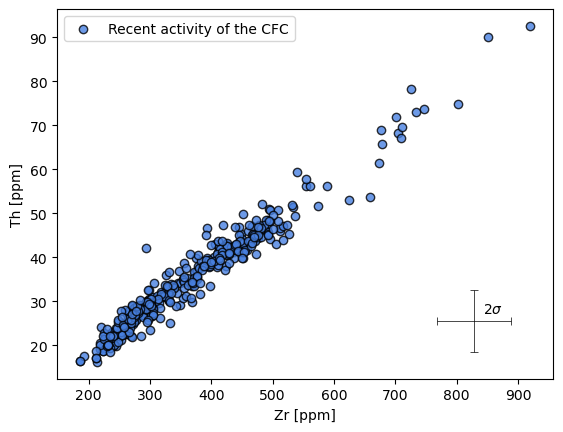

In [26]:
import pandas as pd              # Mengimpor pandas untuk membaca dan mengolah data Excel
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk membuat grafik

def plot_errorbar(x, y, dx, dy, xoffset, yoffset, text, ax):
    # Membuat fungsi custom untuk menggambar error bar + teks

    ax.errorbar(
        x, y,
        xerr=dx, yerr=dy,
        marker='',
        linestyle='',
        elinewidth=.5,
        capthick=0.5,
        ecolor='k',
        capsize=3
    )
    # Membuat error bar tanpa marker (hanya garis error)
    # elinewidth → ketebalan garis error
    # capthick → ketebalan ujung error bar
    # ecolor → warna error bar (hitam)
    # capsize → ukuran “cap” di ujung error bar

    ax.text(x + xoffset, y + yoffset, text)
    # Menambahkan teks pada posisi tertentu (offset dari titik error bar)
    # xoffset dan yoffset digunakan agar teks tidak menimpa garis error


my_dataset1 = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')
# Membaca data Excel dari sheet 'Supp_traces'

x = my_dataset1.Zr
# Mengambil data Zr sebagai sumbu X

y = my_dataset1.Th
# Mengambil data Th sebagai sumbu Y

dx = 60
# Error horizontal (xerr) konstan

dy = 7
# Error vertikal (yerr) konstan


errorbar_x = x.max() - x.max() * 0.1
# Menentukan posisi x untuk error bar (90% dari nilai maksimum Zr)

errorbar_y = y.min() + y.max() * 0.1
# Menentukan posisi y untuk error bar (kombinasi min + 10% max Th)


fig, ax1 = plt.subplots()
# Membuat figure dan axes

ax1.scatter(
    x, y,
    marker='o',
    color='#4881e1',
    edgecolor='k',
    alpha=0.8,
    label='Recent activity of the CFC'
)
# Membuat scatter plot:
# marker='o' → titik bulat
# alpha=0.8 → transparansi
# edgecolor='k' → garis tepi hitam

plot_errorbar(
    errorbar_x,
    errorbar_y,
    dx,
    dy,
    dx/4,
    dy/4,
    r'2$\sigma$',
    ax1
)
# Memanggil fungsi custom errorbar:
# dx/4 dan dy/4 → offset posisi teks
# r'2$\sigma$' → teks matematika (2 sigma)

ax1.legend(loc='upper left')
# Menampilkan legenda di kiri atas

ax1.set_xlabel('Zr [ppm]')
# Label sumbu X

ax1.set_ylabel('Th [ppm]')
# Label sumbu Y

plt.show()
# Menampilkan grafik

In [27]:
import numpy as np  # Mengimpor NumPy untuk operasi matematika, terutama akar dan perhitungan numerik

def sum_ab(a, b, sigma_a, sigma_b):
    # Fungsi untuk penjumlahan dua besaran dengan propagasi ketidakpastian

    z = a + b
    # Menghitung hasil penjumlahan nilai a dan b

    sigma_z = np.sqrt(sigma_a**2 + sigma_b**2)
    # Menghitung ketidakpastian hasil penjumlahan
    # Rumus: σz = √(σa² + σb²) (asumsi error independen)

    return z, sigma_z
    # Mengembalikan nilai hasil (z) dan error-nya (sigma_z)


def division_ab(a, b, sigma_a, sigma_b):
    # Fungsi untuk pembagian dua besaran dengan propagasi ketidakpastian

    z = a / b
    # Menghitung hasil pembagian a terhadap b

    sigma_z = z * np.sqrt((sigma_a/a)**2 + (sigma_b/b)**2)
    # Menghitung ketidakpastian hasil pembagian
    # Rumus propagasi error untuk pembagian:
    # σz/z = √[(σa/a)² + (σb/b)²]

    return z, sigma_z
    # Mengembalikan hasil pembagian dan ketidakpastiannya

In [28]:
import sympy as sym  
# Mengimpor SymPy untuk komputasi simbolik (turunan, aljabar, dll.)

a, b, sigma_a, sigma_b = sym.symbols("a b sigma_a sigma_b")  
# Mendefinisikan variabel simbolik:
# a, b → variabel utama
# sigma_a, sigma_b → ketidakpastian (error) masing-masing variabel


def symbolic_error_prop(func, val_a, val_sigma_a, val_b=0, val_sigma_b=0):
    # Fungsi untuk menghitung propagasi error secara simbolik

    z = sym.lambdify([a, b], func, 'numpy')  
    # Mengubah ekspresi simbolik (func) menjadi fungsi numerik (numpy)
    # agar bisa dievaluasi dengan nilai angka

    sigma_z = sym.lambdify(
        [a, b, sigma_a, sigma_b],
        sym.sqrt(
            (sym.diff(func, a)**2 * sigma_a**2) +
            (sym.diff(func, b)**2 * sigma_b**2)
        ),
        'numpy'
    )
    # Menghitung propagasi error menggunakan rumus umum:
    # σz = √[(∂f/∂a * σa)² + (∂f/∂b * σb)²]
    # sym.diff(func, a) → turunan parsial terhadap a
    # sym.diff(func, b) → turunan parsial terhadap b

    val_z = z(a=val_a, b=val_b)  
    # Menghitung nilai fungsi z dengan memasukkan nilai numerik a dan b

    val_sigma_z = sigma_z(
        a=val_a,
        b=val_b,
        sigma_a=val_sigma_a,
        sigma_b=val_sigma_b
    )
    # Menghitung ketidakpastian (error) berdasarkan nilai input

    return val_z, val_sigma_z  
    # Mengembalikan hasil nilai fungsi dan error-nya

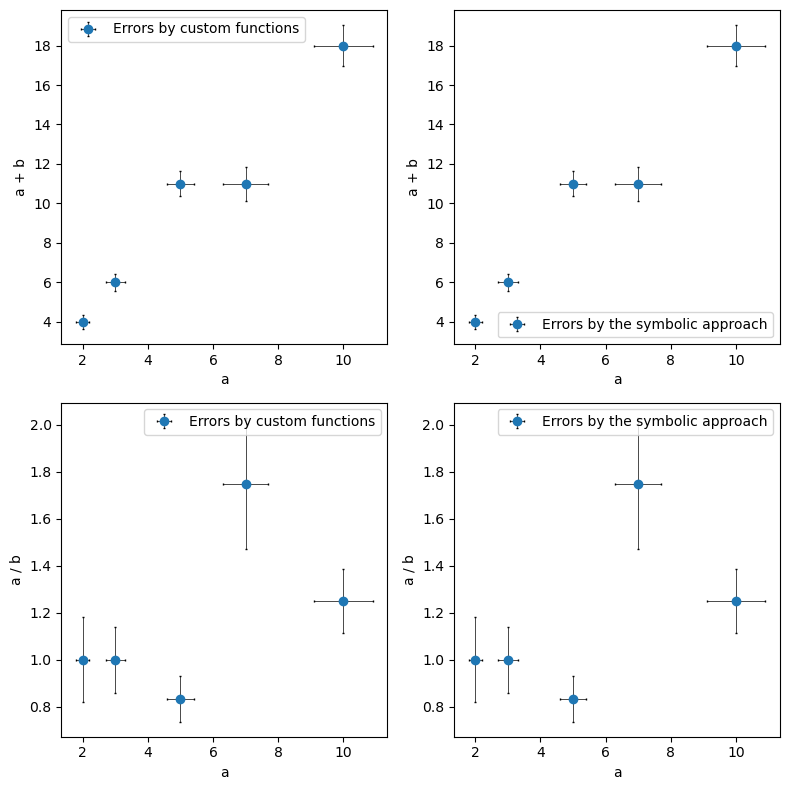

In [29]:
my_a = np.array([2, 3, 5, 7, 10])  
# Data variabel a

my_sigma_a = np.array([0.2, 0.3, 0.4, 0.7, 0.9])  
# Ketidakpastian (error) untuk a

my_b = np.array([2, 3, 6, 4, 8])
# Data variabel b

my_sigma_b = np.array([0.3, 0.3, 0.5, 0.5, 0.5]) 
# Ketidakpastian (error) untuk b


# =========================================
# ERROR PROPAGATION: METODE CUSTOM FUNCTION
# =========================================

my_sum_ab_l, my_sigma_sum_ab_l = sum_ab(
    a=my_a, b=my_b,
    sigma_a=my_sigma_a, sigma_b=my_sigma_b
)
# Menghitung a + b beserta error-nya menggunakan fungsi manual

my_division_ab_l, my_sigma_division_ab_l = division_ab(
    a=my_a, b=my_b,
    sigma_a=my_sigma_a, sigma_b=my_sigma_b
)
# Menghitung a / b beserta error-nya menggunakan fungsi manual


# =========================================
# ERROR PROPAGATION: METODE SYMBOLIC (SYMPY)
# =========================================

my_sum_ab_s, my_sigma_sum_ab_s = symbolic_error_prop(
    func=a + b,
    val_a=my_a,
    val_sigma_a=my_sigma_a,
    val_b=my_b,
    val_sigma_b=my_sigma_b
)
# Menghitung a + b menggunakan metode simbolik (SymPy)

my_division_ab_s, my_sigma_division_ab_s = symbolic_error_prop(
    func=a / b,
    val_a=my_a,
    val_sigma_a=my_sigma_a,
    val_b=my_b,
    val_sigma_b=my_sigma_b
)
# Menghitung a / b menggunakan metode simbolik (SymPy)


# =========================================
# VISUALISASI PERBANDINGAN HASIL
# =========================================

fig = plt.figure(figsize=(8, 8))
# Membuat figure ukuran 8x8 inch


# -------------------------
# SUBPLOT 1: SUM (custom)
# -------------------------

ax1 = fig.add_subplot(2, 2, 1)
# Subplot 1 dari 4

ax1.errorbar(
    x=my_a,
    y=my_sum_ab_l,
    xerr=my_sigma_a,
    yerr=my_sigma_sum_ab_l,
    linestyle='',
    marker='o',
    ecolor='k',
    elinewidth=0.5,
    capsize=1,
    label='Errors by custom functions'
)
# Plot hasil a + b dari metode custom function

ax1.set_xlabel('a')
# Label sumbu X

ax1.set_ylabel('a + b')
# Label sumbu Y

ax1.legend()
# Menampilkan legenda


# -------------------------
# SUBPLOT 2: SUM (symbolic)
# -------------------------

ax2 = fig.add_subplot(2, 2, 2)
# Subplot 2

ax2.errorbar(
    x=my_a,
    y=my_sum_ab_s,
    xerr=my_sigma_a,
    yerr=my_sigma_sum_ab_s,
    linestyle='',
    marker='o',
    ecolor='k',
    elinewidth=0.5,
    capsize=1,
    label='Errors by the symbolic approach'
)
# Plot hasil a + b dari metode SymPy

ax2.set_xlabel('a')
ax2.set_ylabel('a + b')
ax2.legend()


# -------------------------
# SUBPLOT 3: DIVISION (custom)
# -------------------------

ax3 = fig.add_subplot(2, 2, 3)
# Subplot 3

ax3.errorbar(
    x=my_a,
    y=my_division_ab_l,
    xerr=my_sigma_a,
    yerr=my_sigma_division_ab_l,
    linestyle='',
    marker='o',
    ecolor='k',
    elinewidth=0.5,
    capsize=1,
    label='Errors by custom functions'
)
# Plot hasil a / b dari metode manual

ax3.set_xlabel('a')
ax3.set_ylabel('a / b')
ax3.legend()


# -------------------------
# SUBPLOT 4: DIVISION (symbolic)
# -------------------------

ax4 = fig.add_subplot(2,2,4)
# Subplot 4

ax4.errorbar(
    x=my_a,
    y=my_division_ab_s,
    xerr=my_sigma_a,
    yerr=my_sigma_division_ab_s,
    linestyle='',
    marker='o',
    ecolor='k',
    elinewidth=0.5,
    capsize=1,
    label='Errors by the symbolic approach'
)
# Plot hasil a / b dari metode SymPy

ax4.set_xlabel('a')
ax4.set_ylabel('a / b')
ax4.legend()


fig.tight_layout()
# Mengatur layout agar subplot tidak saling tumpang tindih

plt.show()
# Menampilkan seluruh grafik

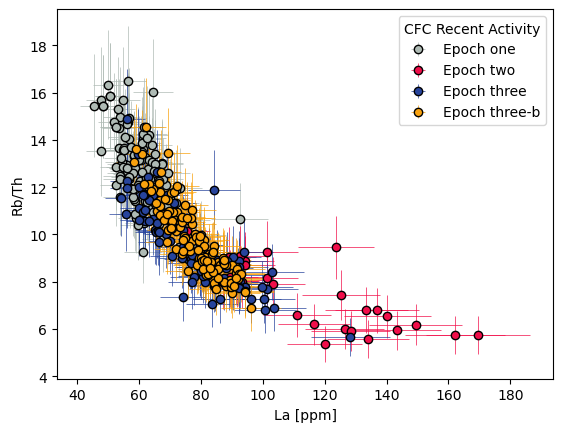

In [30]:
import pandas as pd              # Mengimpor pandas untuk membaca dan mengolah data Excel
import matplotlib.pyplot as plt  # Mengimpor matplotlib untuk membuat grafik
import sympy as sym              # Mengimpor SymPy untuk perhitungan simbolik (error propagation)

# Mendefinisikan variabel simbolik untuk SymPy
a, b, sigma_a, sigma_b = sym.symbols("a b sigma_a sigma_b")


def symbolic_error_prop(func, val_a, val_sigma_a, val_b=0, val_sigma_b=0):
    # Fungsi untuk menghitung propagasi error secara simbolik

    z = sym.lambdify([a, b], func, 'numpy')
    # Mengubah fungsi simbolik menjadi fungsi numerik (numpy)

    sigma_z = sym.lambdify(
        [a, b, sigma_a, sigma_b],
        sym.sqrt(
            (sym.diff(func, a)**2 * sigma_a**2) +
            (sym.diff(func, b)**2 * sigma_b**2)
        ),
        'numpy'
    )
    # Menghitung propagasi error:
    # σz = √[(∂f/∂a · σa)² + (∂f/∂b · σb)²]

    val_z = z(a=val_a, b=val_b)
    # Menghitung nilai fungsi (rasio Rb/Th)

    val_sigma_z = sigma_z(
        a=val_a,
        b=val_b,
        sigma_a=val_sigma_a,
        sigma_b=val_sigma_b
    )
    # Menghitung ketidakpastian (error) dari rasio

    return val_z, val_sigma_z
    # Mengembalikan nilai rasio dan error-nya


# =========================================
# MEMBACA DATA
# =========================================

my_dataset = pd.read_excel(
    'Smith_glass_post_NYT_data.xlsx',
    sheet_name='Supp_traces'
)
# Membaca data dari file Excel sheet 'Supp_traces'


# =========================================
# MENGHITUNG RASIO Rb/Th + ERROR PROPAGATION
# =========================================

ratio_y, sigma_ratio_y = symbolic_error_prop(
    a / b,
    val_a=my_dataset.Rb,
    val_sigma_a=my_dataset.Rb * 0.1,
    val_b=my_dataset.Th,
    val_sigma_b=my_dataset.Th * 0.1
)
# Menghitung rasio Rb/Th menggunakan error propagation simbolik
# asumsi error = 10% dari nilai masing-masing elemen


# Menyimpan hasil ke dalam DataFrame
my_dataset['Rb_Th'] = ratio_y
# Kolom baru: nilai rasio Rb/Th

my_dataset['Rb_Th_1s'] = sigma_ratio_y
# Kolom baru: ketidakpastian (1 sigma) dari rasio


# =========================================
# SET WARNA DAN LABEL EPOCH
# =========================================

epochs = ['one','two','three','three-b']
# Kategori epoch data

colors = ['#afbbb5', '#f10e4a', '#27449c', '#f9a20e']
# Warna masing-masing epoch


# =========================================
# VISUALISASI DATA
# =========================================

fig, ax = plt.subplots()
# Membuat figure dan axes

for epoch, color in zip(epochs, colors):
    # Loop untuk setiap epoch dan warna

    my_data = my_dataset[(my_dataset.Epoch == epoch)]
    # Filter data berdasarkan epoch tertentu

    ax.errorbar(
        x=my_data.La,
        y=my_data.Rb_Th,
        xerr=my_data.La * 0.1,
        yerr=my_data.Rb_Th_1s,
        linestyle='',
        markerfacecolor=color,
        markersize=6,
        marker='o',
        markeredgecolor='k',
        ecolor=color,
        elinewidth=0.5,
        capsize=0,
        label="Epoch " + epoch
    )
    # Plot scatter + error bar untuk tiap epoch
    # xerr = 10% dari La
    # yerr = error hasil propagasi (Rb/Th)


ax.legend(title='CFC Recent Activity')
# Menampilkan legenda dengan judul

ax.set_ylabel('Rb/Th')
# Label sumbu Y

ax.set_xlabel('La [ppm]')
# Label sumbu X

plt.show()
# Menampilkan grafik

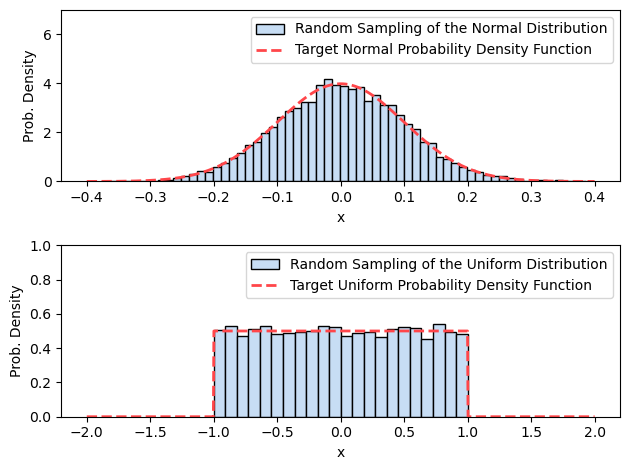

In [31]:
import numpy as np              # Mengimpor NumPy untuk komputasi numerik dan random sampling
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk membuat grafik

# =========================================
# FUNGSI PDF DISTRIBUSI NORMAL
# =========================================
def normal_pdf(x, mu, sigma):
    # Fungsi untuk menghitung probability density function (PDF) distribusi normal

    pdf = 1/(sigma * np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2 / (2*sigma**2))
    # Rumus distribusi normal (Gaussian)

    return pdf
    # Mengembalikan nilai PDF


# =========================================
# FUNGSI PDF DISTRIBUSI UNIFORM
# =========================================
def unifrom_pdf(x, a, b):
    # Fungsi untuk distribusi uniform (catatan: typo nama "unifrom" seharusnya "uniform")

    pdf = np.piecewise(
        x,
        [(x>=a) & (x<=b), (x<a) & (x>b)],
        [1/(b-a), 0]
    )
    # Jika x berada dalam interval [a, b] → nilai konstan 1/(b-a)
    # Jika di luar interval → 0

    return pdf
    # Mengembalikan PDF uniform


# =========================================
# RANDOM SAMPLING DISTRIBUSI NORMAL
# =========================================

my_mu, my_sigma = 0, 0.1
# Mean = 0, standar deviasi = 0.1

sn = np.random.default_rng().normal(
    loc=my_mu,
    scale=my_sigma,
    size=10000
)
# Mengambil 10.000 sampel acak dari distribusi normal


fig = plt.figure()
# Membuat figure untuk plotting


ax1 = fig.add_subplot(2, 1, 1)
# Subplot 1 (normal distribution)

ax1.hist(
    sn,
    density=True,
    bins='auto',
    edgecolor='k',
    color='#c7ddf4',
    label='Random Sampling of the Normal Distribution'
)
# Histogram dari data sampling normal (dinormalisasi jadi PDF)

my_xn = np.linspace(my_mu - 4 * my_sigma, my_mu + 4 * my_sigma, 1000)
# Membuat range x untuk kurva normal teoritis

my_yn = normal_pdf(x=my_xn, mu=my_mu, sigma=my_sigma)
# Menghitung PDF normal teoritis

ax1.plot(
    my_xn,
    my_yn,
    linewidth=2,
    linestyle='--',
    color='#ff464a',
    label='Target Normal Probability Density Function'
)
# Membandingkan histogram dengan kurva normal teoritis

ax1.set_ylim(0.0, 7.0)
# Mengatur batas sumbu Y

ax1.set_xlabel('x')
# Label sumbu X

ax1.set_ylabel('Prob. Density')
# Label sumbu Y

ax1.legend()
# Menampilkan legenda


# =========================================
# RANDOM SAMPLING DISTRIBUSI UNIFORM
# =========================================

my_a, my_b = -1, 1
# Batas bawah dan atas distribusi uniform

su = np.random.default_rng().uniform(
    low=my_a,
    high=my_b,
    size=10000
)
# Mengambil 10.000 sampel dari distribusi uniform


ax2 = fig.add_subplot(2, 1, 2)
# Subplot 2 (uniform distribution)

ax2.hist(
    su,
    density=True,
    bins='auto',
    edgecolor='k',
    color='#c7ddf4',
    label='Random Sampling of the Uniform Distribution'
)
# Histogram sampling uniform (dinormalisasi)

my_xu = np.linspace(-2, 2, 1000)
# Range x untuk kurva uniform

my_yu = unifrom_pdf(x=my_xu, a=my_a, b=my_b)
# Menghitung PDF uniform teoritis

ax2.plot(
    my_xu,
    my_yu,
    linewidth=2,
    linestyle='--',
    color='#ff464a',
    label='Target Uniform Probability Density Function'
)
# Membandingkan histogram dengan distribusi uniform teoritis

ax2.set_ylim(0, 1)
# Batas sumbu Y (PDF uniform maksimum = 1/(b-a))

ax2.set_xlabel('x')
# Label sumbu X

ax2.set_ylabel('Prob. Density')
# Label sumbu Y

ax2.legend()
# Menampilkan legenda


fig.tight_layout()
# Mengatur layout agar tidak overlap

plt.show()
# Menampilkan grafik

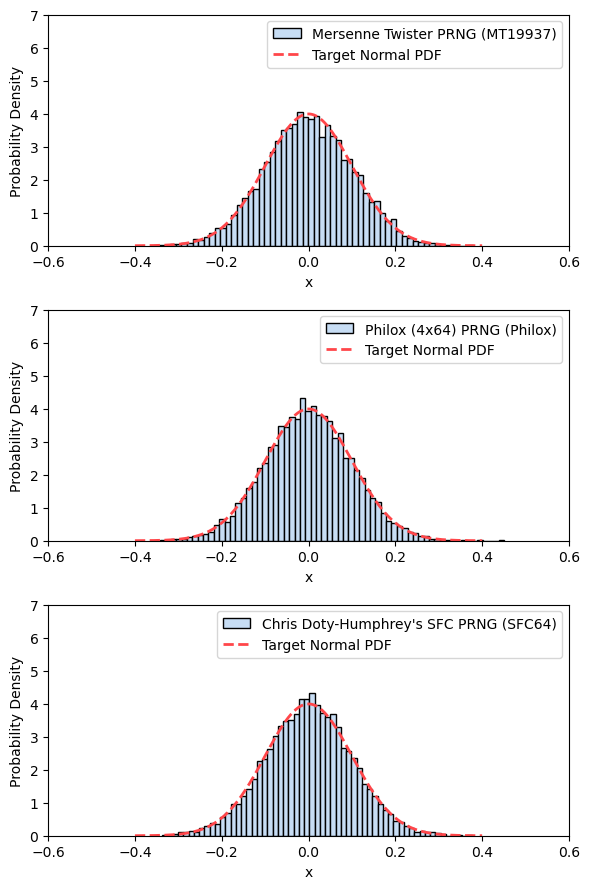

In [32]:
import numpy as np              # Mengimpor NumPy untuk komputasi numerik dan random number generation
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk membuat grafik

def normal_pdf(x, mu, sigma):
    # Fungsi untuk menghitung probability density function (PDF) distribusi normal

    pdf = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x - mu)**2 / (2 * sigma**2))
    # Rumus distribusi normal (Gaussian PDF)

    return pdf
    # Mengembalikan nilai PDF


fig = plt.figure(figsize=(6,9))
# Membuat figure dengan ukuran 6x9 inch


# =========================================
# PARAMETER DISTRIBUSI NORMAL
# =========================================

my_mu, my_sigma = 0, 0.1
# Mean = 0, standar deviasi = 0.1


# =========================================
# PERBANDINGAN PRNG (Pseudo-Random Number Generator)
# =========================================

bit_generators = [
    np.random.MT19937(),   # Generator klasik: Mersenne Twister
    np.random.Philox(),    # Generator modern berbasis counter-based RNG
    np.random.SFC64()      # Generator cepat dengan kualitas tinggi
]
# Tiga jenis algoritma random number generator yang berbeda

names = [
    'Mersenne Twister PRNG (MT19937)',
    'Philox (4x64) PRNG (Philox)',
    "Chris Doty-Humphrey's SFC PRNG (SFC64)"
]
# Nama label untuk masing-masing generator

indexes = [1, 2, 3]
# Posisi subplot dalam figure (3 baris, 1 kolom)


# =========================================
# LOOP UNTUK SETIAP PRNG
# =========================================

for bit_generator, name, index in zip(bit_generators, names, indexes):
    # Menggabungkan generator, nama, dan posisi subplot

    sn = np.random.Generator(bit_generator).normal(
        loc=my_mu,
        scale=my_sigma,
        size=10000
    )
    # Menghasilkan 10.000 sampel dari distribusi normal
    # menggunakan masing-masing PRNG

    ax = fig.add_subplot(3, 1, index)
    # Membuat subplot sesuai index (1, 2, 3)

    ax.hist(
        sn,
        density=True,
        bins='auto',
        edgecolor='k',
        color='#c7ddf4',
        label=name
    )
    # Histogram hasil sampling dari masing-masing PRNG

    my_xn = np.linspace(my_mu - 4 * my_sigma, my_mu + 4 * my_sigma, 1000)
    # Rentang x untuk PDF teoritis normal

    my_yn = normal_pdf(x=my_xn, mu=my_mu, sigma=my_sigma)
    # Menghitung PDF normal teoritis

    ax.plot(
        my_xn,
        my_yn,
        linewidth=2,
        linestyle='--',
        color='#ff464a',
        label='Target Normal PDF'
    )
    # Overlay kurva distribusi normal ideal

    ax.set_ylim(0.0, 7.0)
    # Batas sumbu Y

    ax.set_xlim(my_mu - 6 * my_sigma, my_mu + 6 * my_sigma)
    # Batas sumbu X (lebih lebar dari ±4σ)

    ax.set_xlabel('x')
    # Label sumbu X

    ax.set_ylabel('Probability Density')
    # Label sumbu Y

    ax.legend()
    # Menampilkan legenda


fig.tight_layout()
# Mengatur layout agar subplot tidak tumpang tindih

plt.show()
# Menampilkan semua grafik

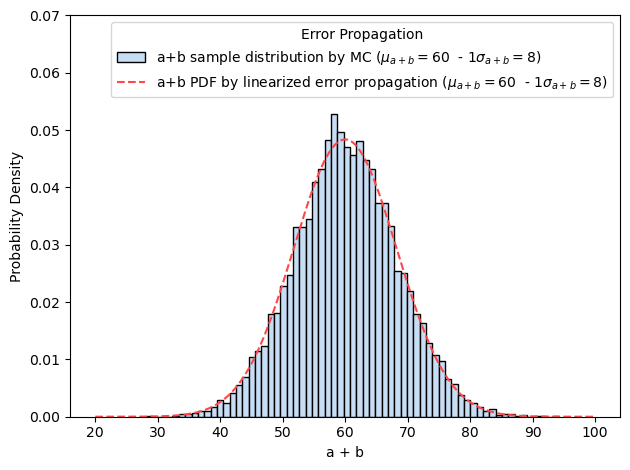

In [34]:
import numpy as np              # Mengimpor NumPy untuk komputasi numerik dan simulasi Monte Carlo
import matplotlib.pyplot as plt # Mengimpor matplotlib untuk membuat grafik

def gaussian(x, mean, std):
    # Fungsi untuk menghitung probability density function (PDF) distribusi normal (Gaussian)

    return 1/(np.sqrt(2*np.pi*std**2))*np.exp(-0.5*(((x - mean)**2)/(std**2)))
    # Rumus PDF Gaussian:
    # menunjukkan distribusi probabilitas dengan mean dan standar deviasi tertentu


my_a, my_sigma_a = 40, 8
# Nilai a dan ketidakpastiannya (sigma a)

my_b, my_sigma_b = 20, 2
# Nilai b dan ketidakpastiannya (sigma b)


n = 10000
# Jumlah sampel untuk simulasi Monte Carlo

a_normal = np.random.default_rng().normal(my_a, my_sigma_a, n)
# Menghasilkan 10.000 sampel acak untuk variabel a (distribusi normal)

b_normal = np.random.default_rng().normal(my_b, my_sigma_b, n)
# Menghasilkan 10.000 sampel acak untuk variabel b


# =========================================
# METODE LINEARIZED (PROPAGASI ERROR ANALITIK)
# =========================================

my_sum_ab_l, my_sigma_sum_ab_l = sum_ab(
    a=my_a,
    b=my_b,
    sigma_a=my_sigma_a,
    sigma_b=my_sigma_b
)
# Menghitung a + b dan ketidakpastian menggunakan metode propagasi error klasik

my_x = np.linspace(20, 100, 1000)
# Membuat range x untuk PDF hasil analitik

my_sum_ab_PDF = gaussian(
    x=my_x,
    mean=my_sum_ab_l,
    std=my_sigma_sum_ab_l
)
# Membuat distribusi normal dari hasil propagasi error (linearized method)


# =========================================
# METODE MONTE CARLO
# =========================================

my_sum_ab_mc = a_normal + b_normal
# Menjumlahkan setiap pasangan sampel acak a dan b

my_sum_ab_mc_mean = my_sum_ab_mc.mean()
# Menghitung mean dari hasil simulasi Monte Carlo

my_sigma_sum_ab_mc_std = my_sum_ab_mc.std()
# Menghitung standar deviasi dari hasil Monte Carlo


# =========================================
# VISUALISASI PERBANDINGAN
# =========================================

fig, ax = plt.subplots()
# Membuat figure dan axes

ax.hist(
    my_sum_ab_mc,
    bins='auto',
    color='#c7ddf4',
    edgecolor='k',
    density=True,
    label=r'a+b sample distribution by MC ($\mu_{a+b} = $' +
          "{:.0f}".format(my_sum_ab_mc_mean) +
          r'  - 1$\sigma_{a+b} = $' +
          "{:.0f}".format(my_sigma_sum_ab_mc_std) + ')'
)
# Histogram hasil Monte Carlo (distribusi empiris)

ax.plot(
    my_x,
    my_sum_ab_PDF,
    color='#ff464a',
    linestyle='--',
    label=r'a+b PDF by linearized error propagation ($\mu_{a+b} = $' +
          "{:.0f}".format(my_sum_ab_l) +
          r'  - 1$\sigma_{a+b} = $' +
          "{:.0f}".format(my_sigma_sum_ab_l) + ')'
)
# Kurva hasil pendekatan linear (analitik Gaussian)

ax.set_xlabel('a + b')
# Label sumbu X

ax.set_ylabel('Probability Density')
# Label sumbu Y

ax.legend(title='Error Propagation')
# Menampilkan legenda dengan judul

ax.set_ylim(0, 0.07)
# Mengatur batas sumbu Y agar grafik lebih jelas

fig.tight_layout()
# Menghindari overlap layout

plt.show()
# Menampilkan grafik